In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
file_name = "1) iris.csv"
df = pd.read_csv(file_name)

df['Petal_Ratio'] = df['petal_length'] / (df['petal_width'] + 1e-5)

X = df.drop(columns=['species'])
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

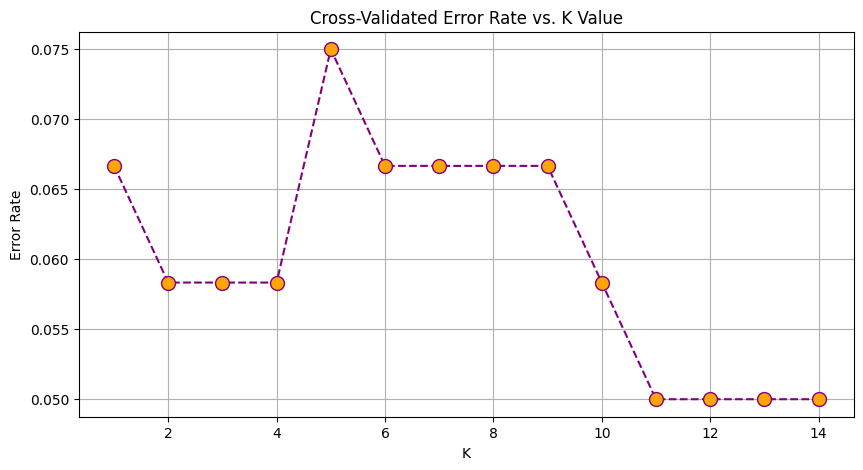

In [9]:
error_rate = []

for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    error_rate.append(1 - np.mean(scores))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), error_rate, color='purple', linestyle='dashed', marker='o', markerfacecolor='orange', markersize=10)
plt.title('Cross-Validated Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid(True)
plt.savefig('knn_k_tuning.png')
plt.show()

In [10]:
best_k = 3
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Final KNN Model Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(report)

Final KNN Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



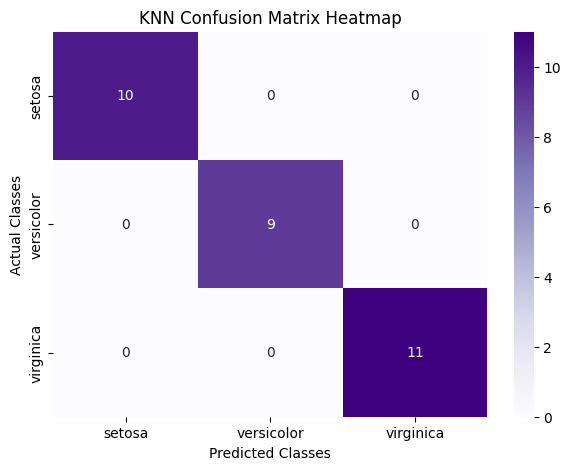

In [11]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=knn_final.classes_, yticklabels=knn_final.classes_)
plt.title('KNN Confusion Matrix Heatmap')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.savefig('knn_confusion_matrix.png')
plt.show()